In [1]:
from data import load_mri_dataframe, get_dataloaders
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from train_generalized_earlystopping import train, dice_loss, bce_loss, bce_dice_loss, tversky_loss
from eval import evaluate, evaluate_losses, evaluate_classification
from hyperparameter_search import create_study
from BaselineUNetParams import BaselineUNet
from OriginalUNet import OriginalUNet
import torch.optim as optim
from ImprovedUNet import ImprovedUNet
import json

In [2]:
df = load_mri_dataframe()

In [3]:
# Load all results
with open("best_params.json", "r") as f:
    all_results = json.load(f)

# Filter for augment=True and model_type="improved"
selected_sudies = [entry for entry in all_results if entry.get("augment") is True and entry.get("model_type") == "improved"]


# Select the one with the highest n_trials
best_study_aug_improved = max(selected_sudies, key=lambda x: x.get("n_trials", 0))

params_aug_improved = best_study_aug_improved["params"]
print("Best params:", params_aug_improved)
print("n_trials:", best_study_aug_improved["n_trials"])
print("Best Dice Score:", best_study_aug_improved["dice_val"])



Best params: {'lr': 0.00022062884670065198, 'batch_size': 4, 'optimizer': 'Adam', 'step_size': 7, 'gamma': 0.49939353507708156, 'num_layers': 4, 'num_filters': 32, 'dropout_rate': 0.445500187703441}
n_trials: 40
Best Dice Score: 0.8199046555222297


[Data] Train images: 1167 ; Val images: 206


Stopped early at epoch 49!
Final Test Dice: 0.8290
Final Test IoU : 0.7437


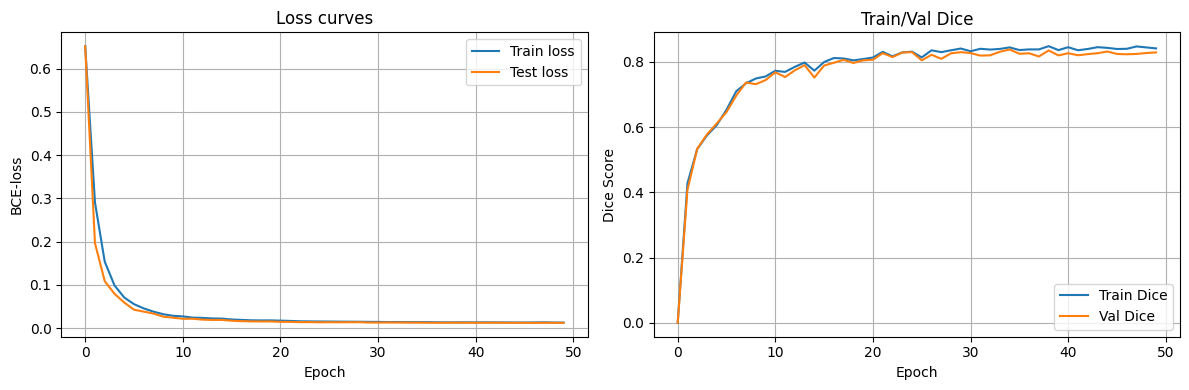

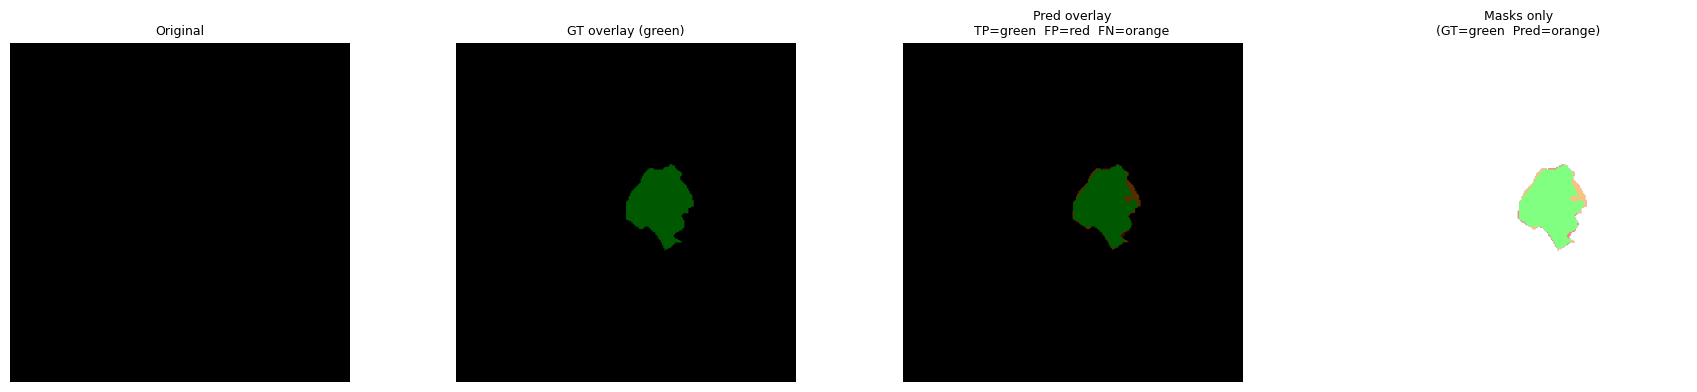

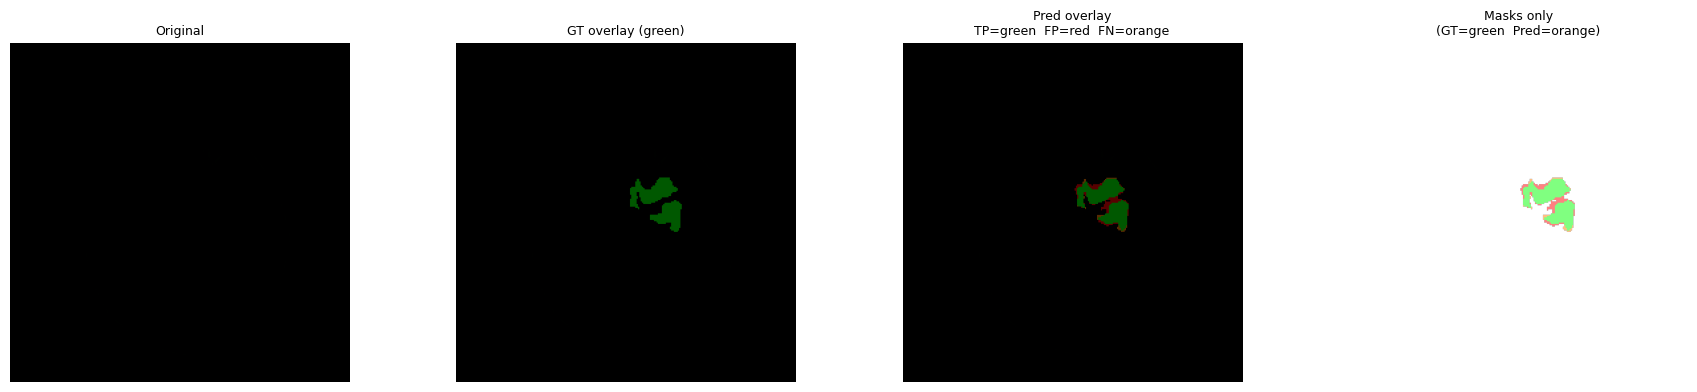

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


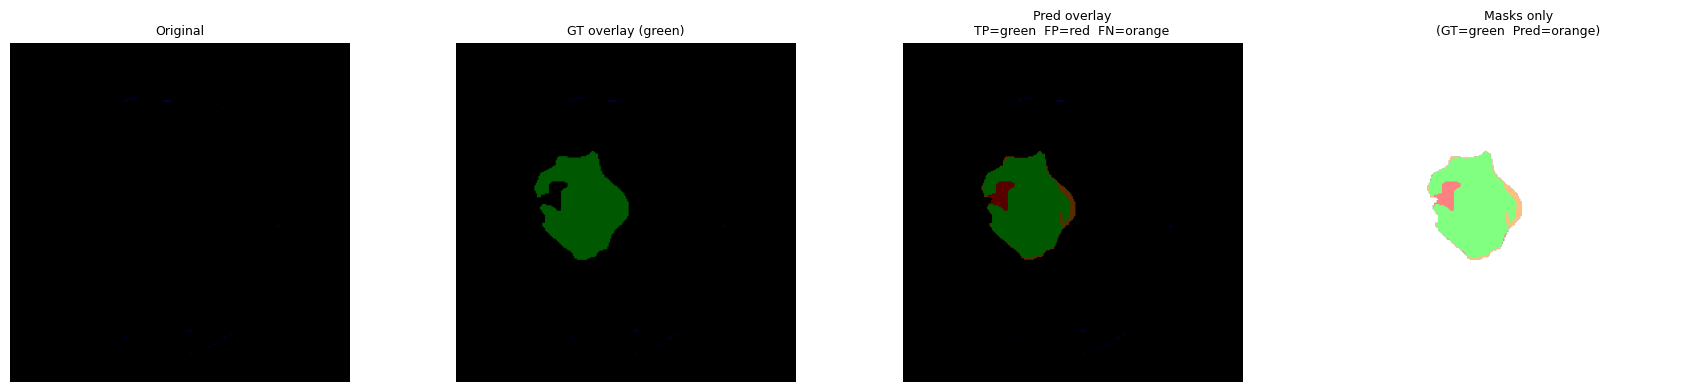

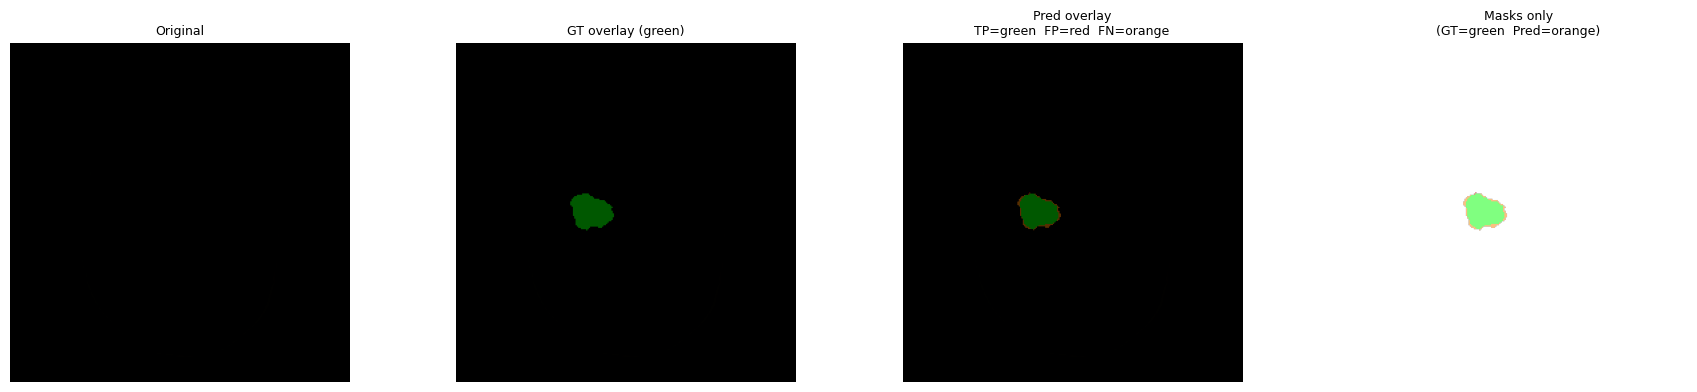

In [ ]:
# Run training with the loaded parameters
device = torch.device('cuda')

train_loader_aug, val_loader_aug = get_dataloaders(df, val_split=0.15, batch_size=params_aug_improved["batch_size"], omit_empty_masks=True, augment=True)

model_aug_improved = ImprovedUNet(num_layers=params_aug_improved['num_layers'], num_filters=params_aug_improved['num_filters'])
trained_model_aug_improved_bce, results_aug_improved_bce = train(
    model_aug_improved,
    train_loader_aug,
    val_loader_aug,
    device,
    lr=params_aug_improved['lr'],
    optimizer_class=optim.Adam if params_aug_improved['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=100,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_aug_improved['step_size'], "gamma": params_aug_improved['gamma']},
    early_stopping=True
)
evaluate(results_aug_improved_bce)

[Data] Train images: 1167 ; Val images: 206


Stopped early at epoch 44!
Final Test Dice: 0.8062
Final Test IoU : 0.7213


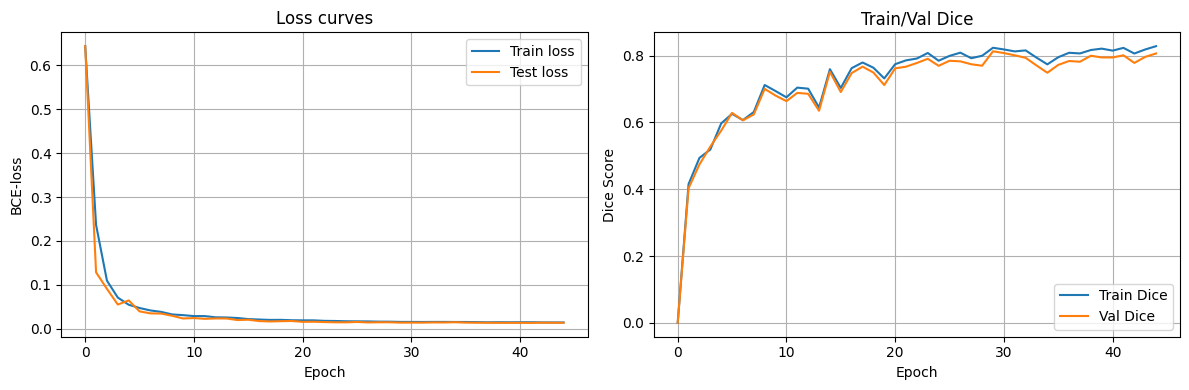

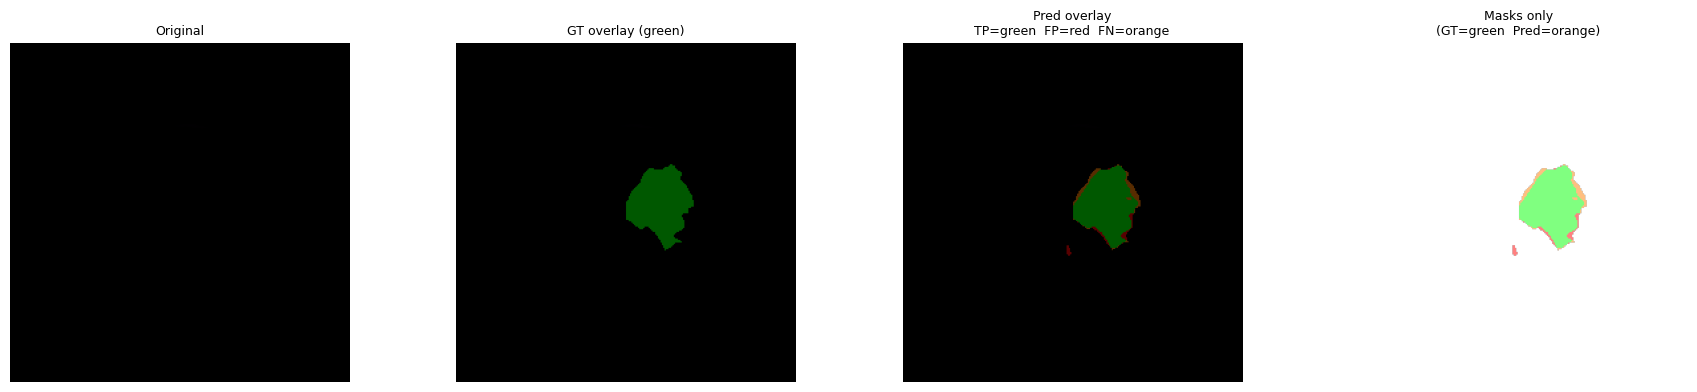

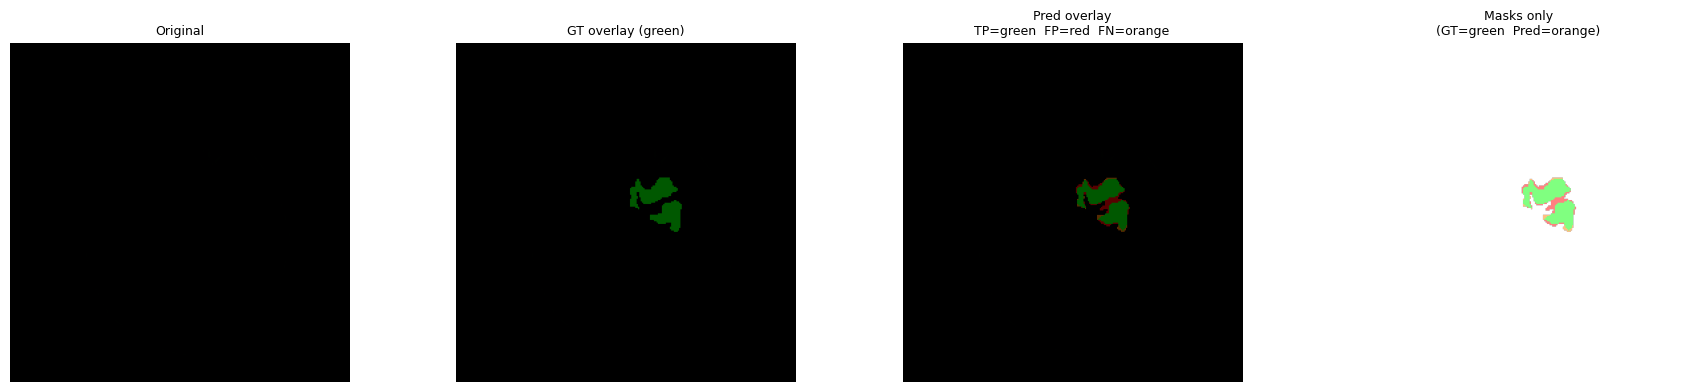

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.44392157].


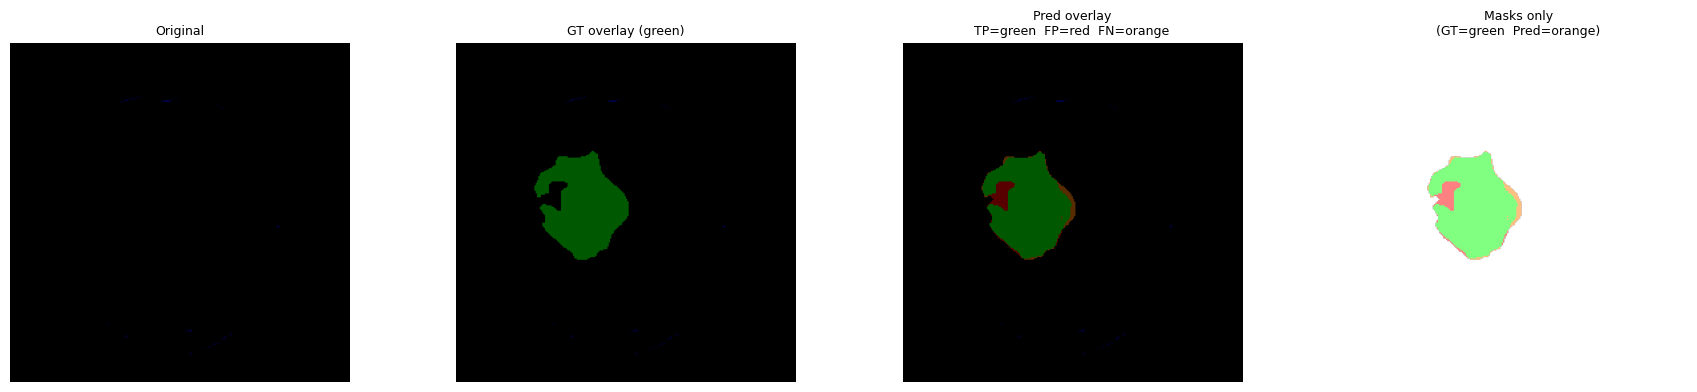

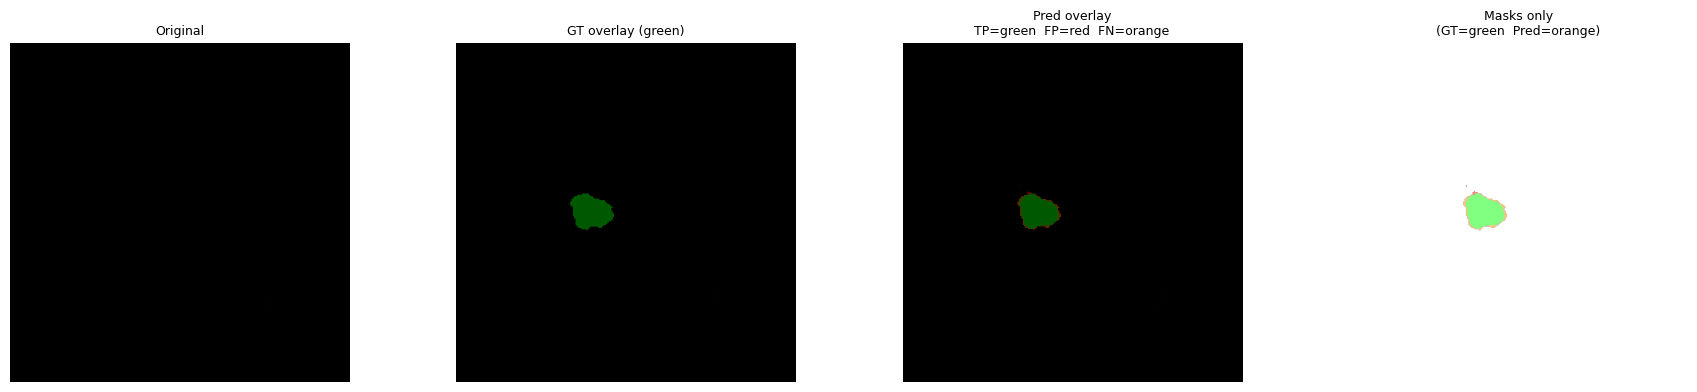

In [ ]:
device = torch.device('cuda')

train_loader_aug, val_loader_aug = get_dataloaders(df, val_split=0.15, batch_size=params_aug_improved["batch_size"], omit_empty_masks=True, augment=True)

model_aug_improved_64 = ImprovedUNet(num_layers=params_aug_improved['num_layers'], num_filters=64)
trained_model_aug_improved_bce_64, results_aug_improved_bce_64 = train(
    model_aug_improved_64,
    train_loader_aug,
    val_loader_aug,
    device,
    lr=params_aug_improved['lr'],
    optimizer_class=optim.Adam if params_aug_improved['optimizer'] == "Adam" else optim.SGD,
    loss_fn=bce_loss,
    epochs=100,
    lr_sched_cls=torch.optim.lr_scheduler.StepLR,
    lr_sched_kwargs={"step_size": params_aug_improved['step_size'], "gamma": params_aug_improved['gamma']},
    early_stopping=True
)
evaluate(results_aug_improved_bce_64)